# Предобработка AFM-изображений


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from src.afm_io import load_afm
from src.preprocess import flatten_plane, flatten_lines, build_substrate_map
from src.visualization import afm_viewer

%matplotlib widget

# Загрузка данных


In [2]:
scan_size_nm, pixel_size_nm, z = load_afm('/home/matsu/AFM-analysis/data/pvp8k/2-5-dmfa-pvp-temp.022', fmt='spm')

assert z.ndim == 2
assert isinstance(z, np.ndarray)

info = pd.DataFrame(z.flatten(), columns=['height_nm'])
info.describe()

,height_nm
count,262144.000000
mean,0.038023
std,9.933018
min,-18.841892
25%,-7.880654
50%,-3.124430
75%,7.375484
max,31.231905


## Визуализация

(<Figure size 1200x500 with 3 Axes>,
 <Axes: title={'center': 'AFM height map'}, xlabel='X (nm)', ylabel='Y (nm)'>,
 <Axes: >,
 <matplotlib.image.AxesImage at 0x7f0cc5092030>)

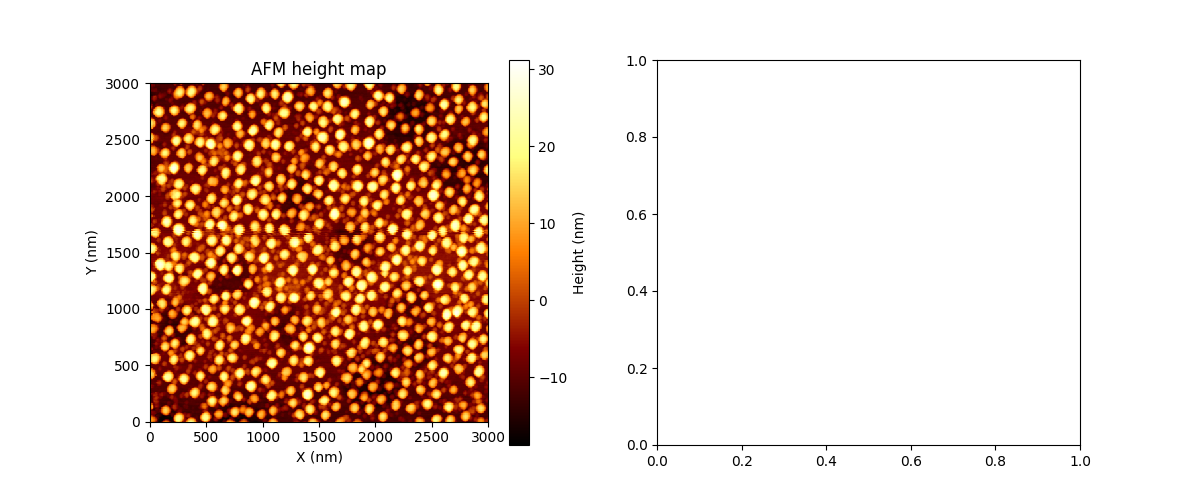

In [3]:
afm_viewer(z, scan_size_nm=scan_size_nm, cmap='afmhot')

# Предобработка
AFM-изображения часто содержат **наклон плоскости** из-за неидеального выравнивания и **артефакты строк**.

- `flatten_plane` -- удаление глобального наклона плоскости (МНК).
- `flatten_lines` -- выравнивание строк (МНК по каждой строке).
- `build_substrate_map` -- вычитание морфологии подложки (morphological opening).


In [4]:
POLY_ORDER = 1
z_raw = z.copy()

z_plane = flatten_plane(z_raw)
z_flat = flatten_lines(z_plane, poly_order=POLY_ORDER)
substrate, z_result, opening_radius, sizes = build_substrate_map(
    z=z_flat, pixel_size_nm=pixel_size_nm, min_size_nm=5
)

print('Изменение среднего значения:', z.mean() - z_result.mean(), 'нм')

Изменение среднего значения: -10.60556423023263 нм


## Визуализация результата

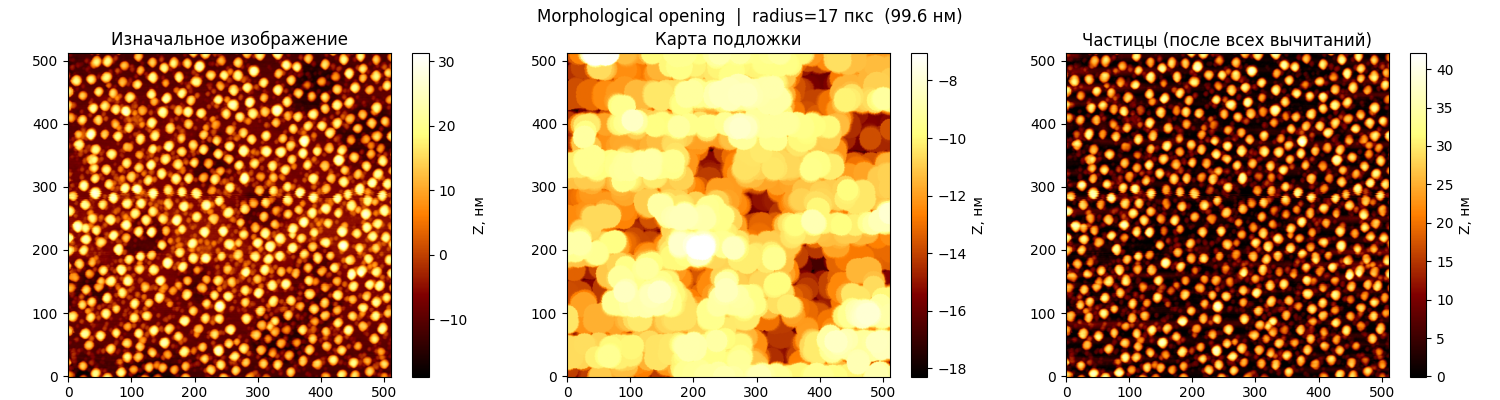

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, data, title in zip(
    axes,
    [z, substrate, z_result],
    ['Изначальное изображение', 'Карта подложки', 'Частицы (после всех вычитаний)']
):
    im = ax.imshow(data, cmap='afmhot', origin='lower')
    plt.colorbar(im, ax=ax, label='Z, нм')
    ax.set_title(title)

plt.suptitle(
    f'Morphological opening  |  radius={opening_radius} пкс  '
    f'({opening_radius * pixel_size_nm:.1f} нм)',
    fontsize=12
)
plt.tight_layout()
plt.show()

# Сохранение


In [6]:
output_dir = Path('data/preprocessed')
output_dir.mkdir(parents=True, exist_ok=True)

np.save(output_dir / 'z_result.npy', z_result)
np.save(output_dir / 'z_flat.npy', z_flat)

np.savez(
    output_dir / 'meta.npz',
    scan_size_nm=scan_size_nm,
    pixel_size_nm=pixel_size_nm,
    opening_radius=opening_radius,
    typical_radius_px=sizes['typical_radius_px'],
    typical_radius_nm=sizes['typical_radius_nm'],
    radii_px=sizes['radii_px'],
    radii_nm=sizes['radii_nm'],
    n_objects=sizes['n_objects'],
    otsu_threshold=sizes['otsu_threshold'],
)

# Сохранение z_result как JPG
fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(z_result, cmap='afmhot', origin='lower')
ax.axis('off')
plt.tight_layout(pad=0)
plt.savefig(output_dir / 'z_result.jpg', dpi=150, bbox_inches='tight')
plt.close()

print(f'Сохранено в {output_dir}')

Сохранено в data/preprocessed
